In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32
L = 2
dim = 2
nx = 32

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [3]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr, SparseNeighborhood
def buildSparseNeighborhood(neighborhood):
    i = neighborhood.row
    j = neighborhood.col

    return SparseNeighborhood(
        row = i,
        col = j,
        numRows = neighborhood.numRows,
        numCols = neighborhood.numCols,

        points_a = neighborhood.points_a,
        points_b = neighborhood.points_b,

        domain = neighborhood.domain,
    )

In [4]:
from diffSPH.neighborhood import buildNeighborhood, computeNeighborhoodStates, filterNeighborhoodByKind, coo_to_csr

mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]
particleState = wcstateToState(particles)
particleStateLR = wcstateToState(particlesLR)

neighborhood, sparseNeighborhood_ = buildNeighborhood(particles, particlesLR, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)


neighborhoodLR, sparseNeighborhoodLR_ = buildNeighborhood(particlesLR, particles, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighborsLR = computeNeighborhoodStates(particleStateLR, sparseNeighborhoodLR_, mode_str, kernel, kernel, True, False, False)
numNeighborsLR = coo_to_csr(neighborsLR.neighbors).rowEntries
# particleStateLR.densities = computeDensity(particleStateLR, kernel, neighborsLR.get('noghost'), SupportScheme.Gather, config)

print('Number of neighbors:', numNeighbors.shape, numNeighbors)
print('Number of neighbors LR:', numNeighborsLR.shape, numNeighborsLR)

Number of neighbors: torch.Size([1024]) tensor([52, 52, 52,  ..., 52, 52, 52], device='cuda:0')
Number of neighbors LR: torch.Size([256]) tensor([208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
        208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208, 208,
    

In [5]:
# particleState = wcstateToState(particles)
# neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)

# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

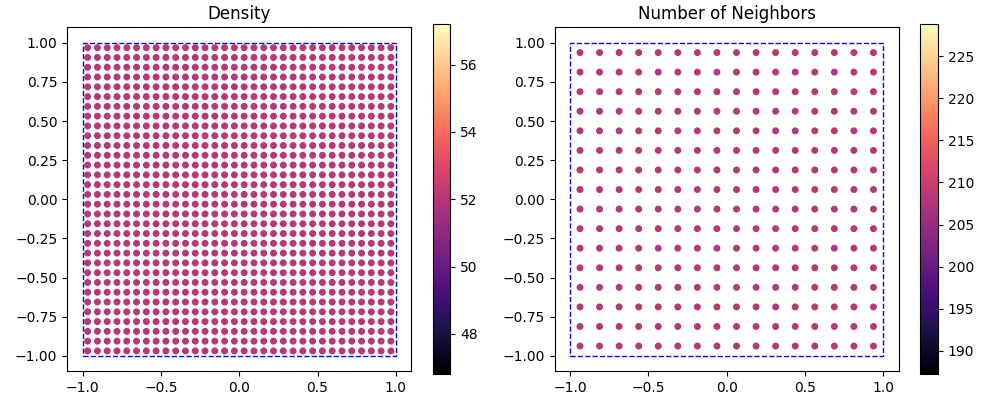

In [6]:
fig, axis = plt.subplots(1,2 , figsize=(10,4), squeeze=False)
markerSize = 16
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Density')

visualizeParticles(fig, axis[0,1], particleStateLR, config['domain'], numNeighborsLR,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Number of Neighbors')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [7]:
from ml import *

In [8]:
inputFeatures = torch.cat([
    particleState.velocities,
    torch.ones_like(particleState.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

inputFeaturesLR = torch.cat([
    particleStateLR.velocities,
    torch.ones_like(particleStateLR.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

gt = particleState.densities.to(device)[:, None]  # ground truth densities

In [9]:
latentSpaceSize = 64
hiddenMLPSize = 128
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

In [10]:
inputEncoder = buildMLPwDict({
 'inputFeatures': inputFeatures.shape[1],
 'output' : 48,
 'activation': 'celu',
 'layout': [hiddenMLPSize] * inputEncoderLayers,
 'norm': False,
 'bias': False,
}
).to(device)

numberOfParameters = sum(p.numel() for p in inputEncoder.parameters())
print(f'Number of parameters in input encoder: {numberOfParameters}')

for i, layer in enumerate(inputEncoder):
    print(f'Layer {i}: {layer}')

encodedInput = inputEncoder(inputFeatures)
encodedInputLR = inputEncoder(inputFeaturesLR)

Number of parameters in input encoder: 144
Layer 0: Linear(in_features=3, out_features=48, bias=False)


In [11]:
from diffSPH.neighborhood import computeSparseDistanceTensor

filteredNeighborhood = neighbors.neighbors
h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood)
sparse_edge_attr = xij_ / h_i[:,None]


# minD = domain.min
# maxD = domain.max
# periodicity = domain.periodic

# dense_xij = (particleState.positions[:,None] - particleState.positions)
# dense_mod_xij = torch.stack([dense_xij.reshape(nx**4, 2)[:,i] if not periodic_i else mod(dense_xij.reshape(nx**4, 2)[:,i], minD[i], maxD[i]) for i, periodic_i in enumerate(periodicity)], dim = -1).reshape(nx**2, nx**2, dim)

# print('dense_xij', dense_mod_xij.shape)
# print(dense_mod_xij.min())

In [12]:
torch.cuda.empty_cache()

In [13]:
from util import *
# adjacency = buildDenseNeighborhood(particleState, domain)
adjacency = buildSparseNeighborhood(particleState, neighbors)

In [25]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency)

edge_attr = xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.row, adjacency.col])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)

transformerFeatures = 16
multiHeads = 4
batch_size = 1
num_nodes = nx**2
latentSpaceSize = encodedInput.shape[-1]
dim = edge_attr.shape[-1]

node_attr = (encodedInput.reshape(1, -1, latentSpaceSize), encodedInputLR.reshape(1, -1, latentSpaceSize))  # Reshape to [B, N, F] for batch processing

print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)

bs = 4
node_attr_batched = (encodedInput.repeat(bs, 1, 1), encodedInputLR.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleState.positions.shape[0]
    cumCols += particleStateLR.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)

edge_attr shape: torch.Size([53248, 2])
edge_index shape: torch.Size([2, 53248])
node_attr shape: torch.Size([1, 1024, 48]) torch.Size([1, 256, 48])
Edge indices for batch 0: torch.Size([2, 53248])
Edge indices for batch 1: torch.Size([2, 53248])
Edge indices for batch 2: torch.Size([2, 53248])
Edge indices for batch 3: torch.Size([2, 53248])
node_attr_batched shape: torch.Size([4, 1024, 48]) torch.Size([4, 256, 48])
edge_attr_batched shape: torch.Size([212992, 2])
edge_indices_batched shape: torch.Size([2, 212992])


In [26]:
from transformer import *

denseNodeTransformer = TransformerLayer(
    latentSpaceSize, transformerFeatures, dim, multiHeads,
    edge_bias = True, edge_gating = True, verbose = False, attentionOp = 'dot', attentionOpIncludeEdge = True, sharedWeights=False, headAggregation='mean', v2 = False).to(device)

num_parameters = sum(p.numel() for p in denseNodeTransformer.parameters())
print(f"Number of parameters in denseNodeTransformer: {num_parameters}")
print(denseNodeTransformer)

Number of parameters in denseNodeTransformer: 29052
TransformerLayer(
  (W_Q): Linear(in_features=48, out_features=64, bias=False)
  (W_K): Linear(in_features=48, out_features=64, bias=False)
  (W_V): Linear(in_features=48, out_features=64, bias=False)
  (W_E): Linear(in_features=2, out_features=4, bias=True)
  (W_E_gate): Linear(in_features=2, out_features=64, bias=True)
  (activation): CELU(alpha=1.0)
  (W_O): Linear(in_features=16, out_features=48, bias=False)
  (layer_norm1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
  (layer_norm2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
  (ffn): Sequential(
    (0): Linear(in_features=48, out_features=192, bias=True)
    (1): CELU(alpha=1.0)
    (2): Linear(in_features=192, out_features=48, bias=True)
  )
  (attentionActivation): LeakyReLU(negative_slope=0.2)
)


In [27]:
transformerOutput = denseNodeTransformer(node_attr, edge_attr, edge_index)
print(f'Transformer output shape: {transformerOutput.shape}')

Transformer output shape: torch.Size([1, 1024, 48])


In [28]:
transformerOutput_batched = denseNodeTransformer(node_attr_batched, edge_attr_batched, edge_indices_batched)
print(f'Transformer output shape: {transformerOutput_batched.shape}')

Transformer output shape: torch.Size([4, 1024, 48])


In [29]:
print(transformerOutput[0])

tensor([[-0.3558,  1.7523,  0.6287,  ...,  2.2088, -0.5195, -0.1962],
        [-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        [-0.3558,  1.7523,  0.6287,  ...,  2.2088, -0.5195, -0.1962],
        ...,
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955],
        [-0.3587,  1.7507,  0.6306,  ...,  2.2106, -0.5155, -0.1989],
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955]],
       device='cuda:0', grad_fn=<SelectBackward0>)


In [30]:
print(transformerOutput[0])
print(transformerOutput_batched[1])

print(torch.all(torch.isclose(transformerOutput[0], transformerOutput_batched[0], atol= 1e-6)))

diff = (transformerOutput[0] - transformerOutput_batched[0])
print(f'Difference: min: {diff.min()}, max: {diff.max()}, mean: {diff.mean()}')

tensor([[-0.3558,  1.7523,  0.6287,  ...,  2.2088, -0.5195, -0.1962],
        [-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        [-0.3558,  1.7523,  0.6287,  ...,  2.2088, -0.5195, -0.1962],
        ...,
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955],
        [-0.3587,  1.7507,  0.6306,  ...,  2.2106, -0.5155, -0.1989],
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955]],
       device='cuda:0', grad_fn=<SelectBackward0>)
tensor([[-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        [-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        [-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        ...,
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955],
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955],
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955]],
       device='cuda:0', grad_fn=<SelectBackward0>)
tensor(False, device='cuda:0')

In [31]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency)

edge_attr = -xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.col, adjacency.row])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)

transformerFeatures = 16
multiHeads = 4
batch_size = 1
num_nodes = nx**2
latentSpaceSize = encodedInput.shape[-1]
dim = edge_attr.shape[-1]

node_attr = (encodedInputLR.reshape(1, -1, latentSpaceSize), encodedInput.reshape(1, -1, latentSpaceSize))  # Reshape to [B, N, F] for batch processing

print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)

bs = 4
node_attr_batched = (encodedInputLR.repeat(bs, 1, 1), encodedInput.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleStateLR.positions.shape[0]
    cumCols += particleState.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)

edge_attr shape: torch.Size([53248, 2])
edge_index shape: torch.Size([2, 53248])
node_attr shape: torch.Size([1, 256, 48]) torch.Size([1, 1024, 48])
Edge indices for batch 0: torch.Size([2, 53248])
Edge indices for batch 1: torch.Size([2, 53248])
Edge indices for batch 2: torch.Size([2, 53248])
Edge indices for batch 3: torch.Size([2, 53248])
node_attr_batched shape: torch.Size([4, 256, 48]) torch.Size([4, 1024, 48])
edge_attr_batched shape: torch.Size([212992, 2])
edge_indices_batched shape: torch.Size([2, 212992])


In [32]:
transformerOutput = denseNodeTransformer(node_attr, edge_attr, edge_index)
print(f'Transformer output shape: {transformerOutput.shape}')

Transformer output shape: torch.Size([1, 256, 48])
